In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# We load the collected Bitcoin price data, convert the timestamps to datetime format,
# and prepare it for time series analysis.

# Load CSV
df = pd.read_csv("bitcoin_price_data.csv")

# Convert timestamp column to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Set timestamp as index
df.set_index("timestamp", inplace=True)

# Sort by time (just in case)
df.sort_index(inplace=True)

# Display the first few rows
print(df.head())

                     price
timestamp                 
2025-04-22 10:37:32  90367
2025-04-22 10:37:42  90388
2025-04-22 10:37:52  90388
2025-04-22 10:38:02  90388
2025-04-22 10:38:12  90388


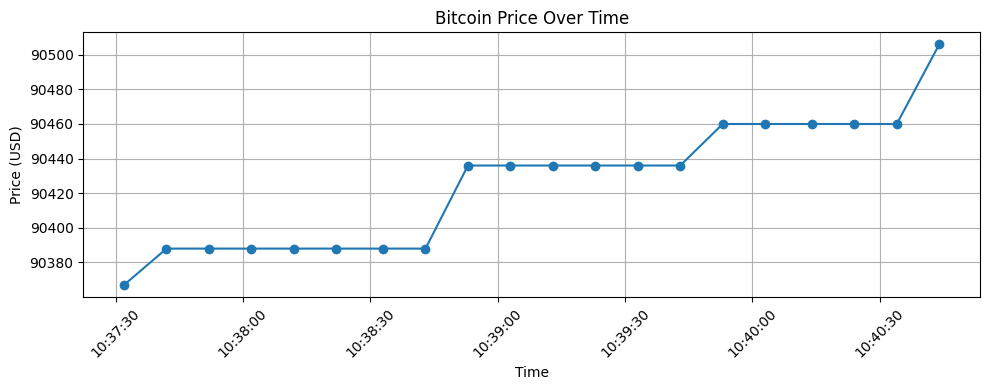

In [2]:
# Plot the raw time series to understand the trend
plt.figure(figsize=(10, 4))
plt.plot(df.index, df["price"], marker='o')
plt.title("Bitcoin Price Over Time")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)

# Show the plot
plt.show()

In [3]:
# Installing the PyMC library (version 5.10.4) for Bayesian modeling

!pip install pymc==5.10.4 --quiet

In [4]:
import pymc as pm
import numpy as np

# Prepare data for modeling
df["time_idx"] = np.arange(len(df))  # Use an integer time index
x = df["time_idx"].values
y = df["price"].values

# Standardize x for better convergence
x_mean = x.mean()
x_std = x.std()
x_scaled = (x - x_mean) / x_std

In [10]:
# Building a Bayesian linear regression model using PyMC
# The goal is to model the relationship between time and Bitcoin price

with pm.Model() as model:

    # Prior for the intercept (alpha), centered around 90000 (approximate Bitcoin price)
    alpha = pm.Normal("alpha", mu=90000, sigma=1000)

    # Prior for the slope (beta), allows for small positive/negative trends
    beta = pm.Normal("beta", mu=0, sigma=50)

    # Prior for the noise in the data (standard deviation), must be positive
    sigma = pm.HalfNormal("sigma", sigma=100)

    # Expected mean of the observed data based on the linear relationship
    mu = alpha + beta * x_scaled

    # Likelihood: how the observed prices are assumed to be distributed
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    # Run the sampler to get posterior distributions of the parameters
    trace = pm.sample(1000, tune=1000, target_accept=0.95, return_inferencedata=True)

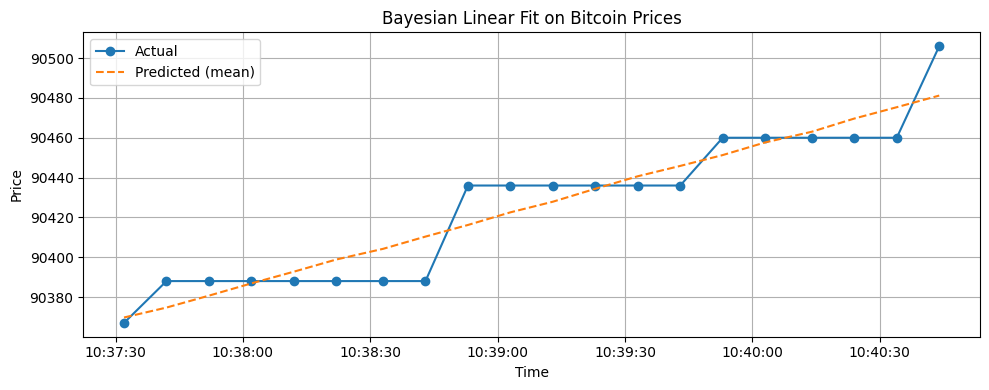

In [11]:
import matplotlib.pyplot as plt
import arviz as az

# Generate predictions from the model using the posterior samples
with model:
    posterior_predictive = pm.sample_posterior_predictive(trace, var_names=["y_obs"])

# Take the mean of the predicted values across all chains and draws
# This gives the average predicted price for each time point
y_preds = posterior_predictive.posterior_predictive["y_obs"].mean(dim=["chain", "draw"]).values

# Plot the actual vs predicted prices
plt.figure(figsize=(10, 4))
plt.plot(df.index, y, label="Actual", marker='o')                # Actual data
plt.plot(df.index, y_preds, label="Predicted (mean)", linestyle='--')  # Model prediction

# Add labels and title
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Bayesian Linear Fit on Bitcoin Prices")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gaussian Random Walk

In [12]:
import pymc as pm
import numpy as np

# Reset x and y (in case modified earlier)
x = np.arange(len(df))         # integer time index
y = df["price"].values         # observed prices

with pm.Model() as state_space_model:
    # Prior for the standard deviation of the random walk
    sigma_rw = pm.HalfNormal("sigma_rw", sigma=50)

    # Define the latent trend as a Gaussian Random Walk
    trend = pm.GaussianRandomWalk("trend", sigma=sigma_rw, shape=len(x))

    # Observation noise
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=50)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=trend, sigma=sigma_obs, observed=y)

    # Sampling
    trace_ss = pm.sample(1000, tune=1000, target_accept=0.95, return_inferencedata=True)


/usr/local/lib/python3.11/dist-packages/pymc/distributions/timeseries.py:293: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


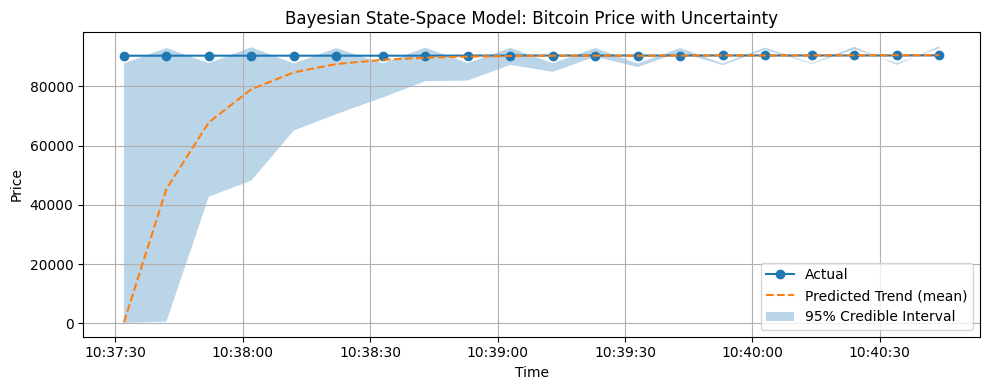

In [17]:
import matplotlib.pyplot as plt
import arviz as az

# Get posterior samples for the trend variable from the model
trend_samples = trace_ss.posterior["trend"]

# Compute the mean of the predicted trend across all samples
trend_mean = trend_samples.mean(dim=["chain", "draw"]).values

# Compute the 95% credible interval for each time point
# .to_array() gives us an xarray with both lower and upper bounds
trend_hpd = az.hdi(trend_samples, hdi_prob=0.95).to_array()

# Convert to NumPy and reshape to (2, number of time steps)
trend_hpd = trend_hpd.values.reshape(2, -1)

# Plot the actual price data
plt.figure(figsize=(10, 4))
plt.plot(df.index, y, label="Actual", marker='o')

# Plot the average predicted trend
plt.plot(df.index, trend_mean, label="Predicted Trend (mean)", linestyle='--')

# Shade the area between the lower and upper credible bounds
plt.fill_between(
    df.index,
    trend_hpd[0],  # Lower bound
    trend_hpd[1],  # Upper bound
    alpha=0.3,
    label="95% Credible Interval"
)

# Add labels and grid
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Bayesian State-Space Model: Bitcoin Price with Uncertainty")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


*   I have performed Gaussian Random Walk for Price using a Bayesian state-space model built with PyMC.

*   This model allows the trend to change over time instead of assuming it stays constant or follows a straight line.

* This model also allows the trend to change over time instead of assuming it stays constant or follows a straight line.

* I trained model to generate predictions for each time step and calculate 95% credible intervals to represent uncertainty.

* The plotted a graph shows:

  * The actual Bitcoin prices (as blue dots)
  * The predicted trend (as an orange dashed line)
  * The credible interval (as a shaded blue area)

* From the graph, we can see that:

  * The model successfully captures the upward trend in prices.
  * The uncertainty is wider at the beginning, because the model has seen less data.
  * The credible interval becomes narrower as more data comes in, showing that the model becomes more confident over time.

* This approach is useful because it not only gives predictions, but also shows how confident the model is in those predictions — which is important for decision-making.

In [25]:
# Forecasting Future Prices with GRW

# Set how many steps ahead to forecast
n_forecast = 10
n_total = len(df) + n_forecast  # total length = observed + forecast

with pm.Model() as grw_forecast_model:
    # Prior for standard deviation of the random walk
    sigma_rw = pm.HalfNormal("sigma_rw", sigma=50)

    # Gaussian Random Walk for total length (observed + future)
    trend = pm.GaussianRandomWalk("trend", sigma=sigma_rw, shape=n_total)

    # Observation noise
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=50)

    # Likelihood only applies to observed part
    y_obs = pm.Normal("y_obs", mu=trend[:len(df)], sigma=sigma_obs, observed=y)

    # Sample from posterior
    trace_grw_forecast = pm.sample(1000, tune=1000, target_accept=0.95, return_inferencedata=True)

/usr/local/lib/python3.11/dist-packages/pymc/distributions/timeseries.py:293: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


<ipython-input-26-542a9b870646>:14: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  future_index = pd.date_range(start=df.index[-1], periods=n_forecast + 1, freq="10S")[1:]


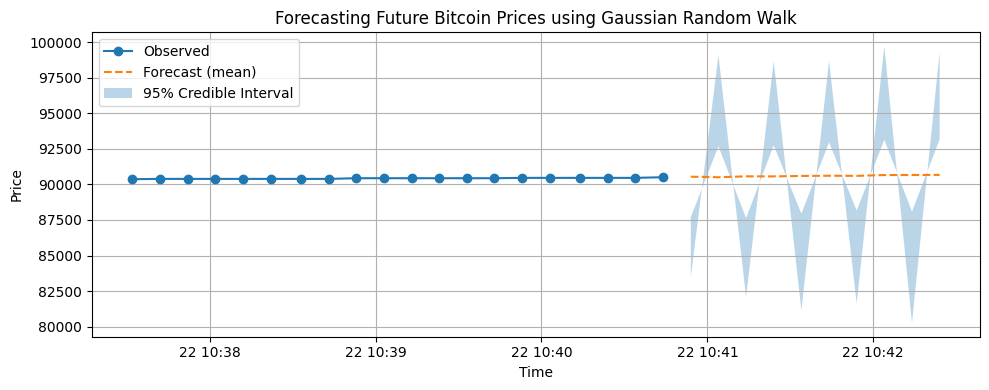

In [26]:
# Plotting future forecast

# Extract trend samples (includes future)
trend_samples = trace_grw_forecast.posterior["trend"]

# Split into observed and forecast parts
observed_len = len(df)
future_len = n_forecast

trend_mean = trend_samples.mean(dim=["chain", "draw"]).values
trend_hdi = az.hdi(trend_samples, hdi_prob=0.95).to_array().values.reshape(2, -1)

# Time index for future points
future_index = pd.date_range(start=df.index[-1], periods=n_forecast + 1, freq="10S")[1:]

# Plot
plt.figure(figsize=(10, 4))

# Actual data
plt.plot(df.index, y, label="Observed", marker='o')

# Forecasted mean and interval
plt.plot(future_index, trend_mean[observed_len:], label="Forecast (mean)", linestyle='--')
plt.fill_between(future_index, trend_hdi[0][observed_len:], trend_hdi[1][observed_len:], alpha=0.3, label="95% Credible Interval")

plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Forecasting Future Bitcoin Prices using Gaussian Random Walk")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


* I used a Bayesian Gaussian Random Walk (GRW) model to analyze and forecast Bitcoin prices.

* The model assumes that the price trend can evolve freely over time, without assuming a fixed slope or pattern.

* After training the model on observed data, I extended the time series to forecast 10 future time steps.

* The plot shows:

  * A stable forecast mean, since the model assumes price follows the existing trend unless a strong signal changes it

  * A wide credible interval, which increases over time — showing that the model is less certain the further it predicts into the future